# Clustering and Pattern Analysis 

This tutorial covers the analysis steps of TF-MInDi:
- Working with a GPU backend
- Clustering seqlets with different resolutions
- Evaluating clustering quality
- Iterative refinement and filtering
- Generating motif patterns using {func}`~tfmindi.tl.create_patterns` from clusters

In [1]:
import tfmindi as tm

DATA_DIR = "../../../../data/tfmindi/"

/home/VIB.LOCAL/lukas.mahieu/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Load preprocessed data from previous tutorial
adata = tm.load_h5ad(DATA_DIR + "seqlets.h5ad")

To cluster the seqlets, we use {func}`~tfmindi.tl.cluster_seqlets`.  

This function performs the following steps:
1. PCA on similarity matrix
2. Compute neighborhood graph
3. Generate t-SNE embedding
4. Leiden clustering at specified resolution
5. Calculate mean contribution scores from stored seqlet matrices
6. Assign DBD annotations based on top motif similarity per seqlet
7. Map leiden clusters to consensus DBD annotations using binomial tests

Clustering benefits greatly in terms of speed from having a GPU (and having the GPU version of tfmindi installed), since we use [rapids-singlecell](https://rapids-singlecell.readthedocs.io/en/latest/index.html) instead of default `scanpy` for these functions.  
You can check what backend you have available with {func}`~tfmindi.get_backend`. If no GPU is available, `tfmindi` will fallback to the default CPU implementation.  

In [2]:
print(f"Using {tm.get_backend()}")

Using gpu


In [4]:
tm.tl.cluster_seqlets(adata, resolution=3.0)

Using GPU-accelerated backend for clustering operations...
Computing PCA...
Computing neighborhood graph...
Computing t-SNE embedding...
[2025-11-19 15:53:55.472] [CUML] [warning] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...
Performing Leiden clustering with resolution 3.0...
Clustering complete. Found 61 clusters.
DBD annotation coverage: 679653/679653 seqlets


This not only clustered the seqlets, but, if you have DBD annotations in your anndata, it will have assigned each cluster to a major TF-family (based on the most common annotation per cluster. If the most common are NaNs, then the cluster will be NaN).  
This info is located in the `Anndata.obs["cluster_dbd"]`. We will use this column in our plotting to visualize the seqlet patterns.

In [5]:
adata.obs["cluster_dbd"].value_counts()

cluster_dbd
C2H2 ZF             169386
Homeodomain          70333
SMAD                 67845
bHLH                 56834
MADS box             49873
HMG/Sox              49520
bZIP                 49092
E2F                  23924
Homeodomain; POU     23210
Nuclear receptor     22926
Ets                  20637
RFX                  19832
Grainyhead           16897
T-box                14333
Forkhead             12932
Rel                   8057
IRF                   3023
GATA                   999
Name: count, dtype: int64

In [6]:
# count number of NaNs (clusters where the majority of seqlets do not have a DBD annotation)
print(adata.obs["cluster_dbd"].isna().sum(), "NaN values")

0 NaN values


## Plotting our TF-MInDi clusters

`tfmindi` has a bunch of plotting functionality to investigate our extracted seqlets. All of these can be found in the `tfmindi.pl` module.  
For example, there is a {func}`~tfmindi.pl.tsne` function that visualizes seqlet clusters in t-SNE space as a scatter plot. 

```{note}
All of `tfmindi.pl` plotting functionality uses the {func}`~tfmindi.pl.render_plot` function to customize the plot's layout.  
You should look at its argument if you want to customize your plots (don't call this function directly though).
```

We strongly recommend to visualize the average contribution of each seqlet. Noisy seqlets will have a low contribution and are often localized in the middle of the tSNE.

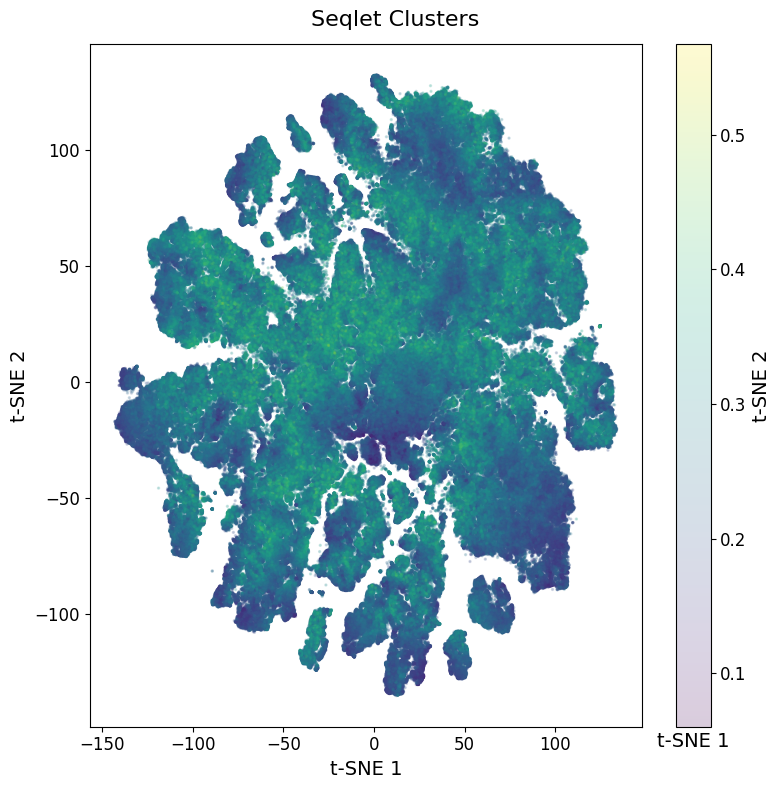

In [7]:
%matplotlib inline
tm.pl.tsne(
    adata,
    color_by="mean_contrib",
    s=2,
    alpha=0.2,
    save_path=DATA_DIR + "seqlets_tsne_mean_contrib.png",
)

The seqlets with low contribution scores seem to be relatively spread evenly between all the clusters.  
There are some clusters on the top that seem a bit lower in quality, but for now we'll just keep that in mind and keep these seqlets in.  
You could consider removing these from your `Anndata` object, or rerunning the seqlet extraction functions with a stricter confidence score. 


We can also visualize the TF family annotation.

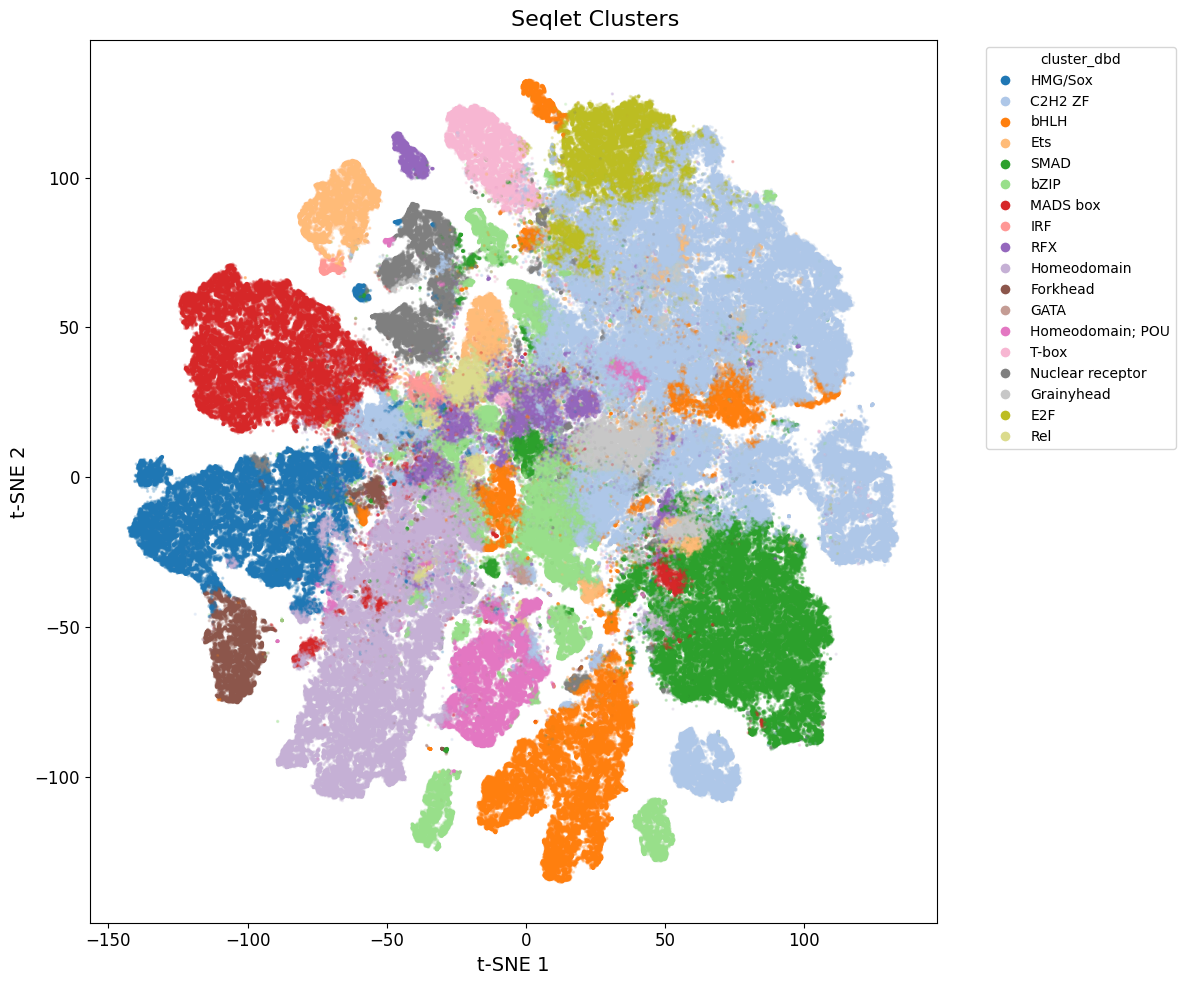

In [8]:
tm.pl.tsne(
    adata,
    color_by="cluster_dbd",
    width=12,
    height=10,
    s=2,
    alpha=0.2,
)

You can consider rerunning the clustering with a different resolution if you don't feel like the annotations are specific enough.  
For now, we will continue with this resolution.

In [9]:
# save the anndata so we don't need to cluster again
tm.save_h5ad(adata, DATA_DIR + "seqlets_clustered.h5ad")

... storing 'seqlet_dbd' as categorical
... storing 'cluster_dbd' as categorical


## Generating Logos per cluster

Next, we will generate a logo, or a consensus {class}`tfmindi.Pattern`, for each cluster of seqlets.   
For this, all seqlets per cluster will be aligned using tomtom and a consensus "root pattern" will be found based on lowest similarity to all other motifs in the cluster.    

In [2]:
adata = tm.load_h5ad(DATA_DIR + "seqlets_clustered.h5ad")

In [10]:
patterns = tm.tl.create_patterns(
    adata,
    method="tomtom",  # options: 'kmer', 'tomtom'
    max_n=1000,  # sample up to n seqlets per cluster to speed things up
)

Creating patterns for 61 clusters...


```{tip}

You can save patterns using {func}`tfmindi.save_patterns` and load them back using {func}`tfmindi.load_patterns`.
```

In [11]:
# example pattern associated with cluster 59
patterns["59"]

Pattern(cluster=59, n_seqlets=1000, len=31, consensus='AATTGTAATTAGCATTATTT...', mean_ic=0.28, dbd=Homeodomain)

These logo's can now be visualized. For example, on top of the tSNE of seqlets.

We can use a separate {func}`~tfmindi.pl.tsne_logos` to show our previous clusters together with our extracted patterns per cluster.  

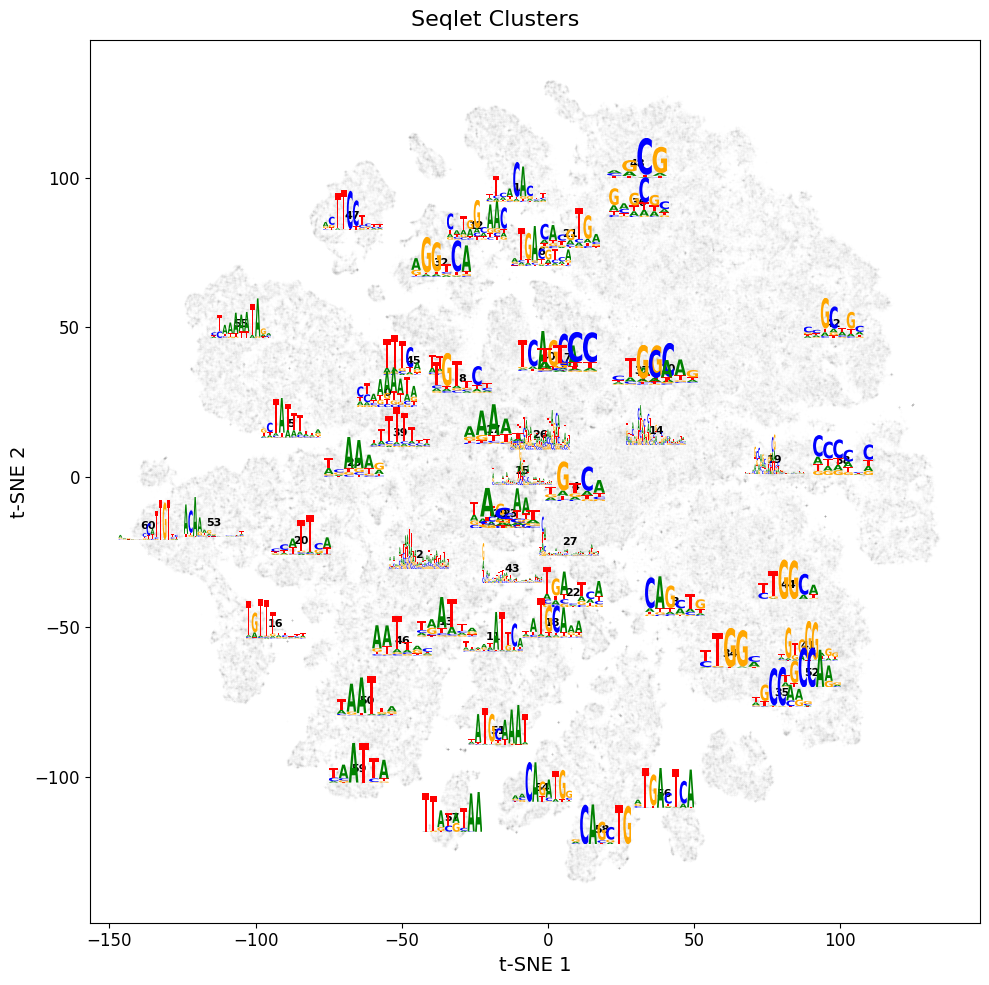

In [12]:
tm.pl.tsne_logos(
    adata,
    patterns,
    gray_background=True,  # ignore cmap and make all points gray for better pattern visibility
    min_nucleotides=4,  # ignore trimmed patterns less than 4 nucleotides (heterogeneous clusters)
    width=10,
    height=10,
    s=0.3,
    alpha=0.01,  # background alpha
    logo_height=0.4,
    logo_width=0.6,
    ic_threshold=0.2,  # nucleotides in pattern below this will be trimmed
    min_seqlets=10,  # ignore patterns with less than this many seqlets in the cluster
)

## Inspecting DNA-Binding Domains

During creation of the consensus patterns cluster, since each cluster has an assigned DNA-Binding Domain (DBD), our patterns were each assigned to a DBD.   
We can visualize the motifs for each of the matched DBD using {func}`~tfmindi.pl.dbd_logos`.  
Since we'll have multiple patterns with the same DBD, for each DBD we visualize one representative logo with the highest information content (IC).   
If a Pattern is too short after trimming for IC content, the next "long enough" pattern will be shown (unless no pattern is long enough). 

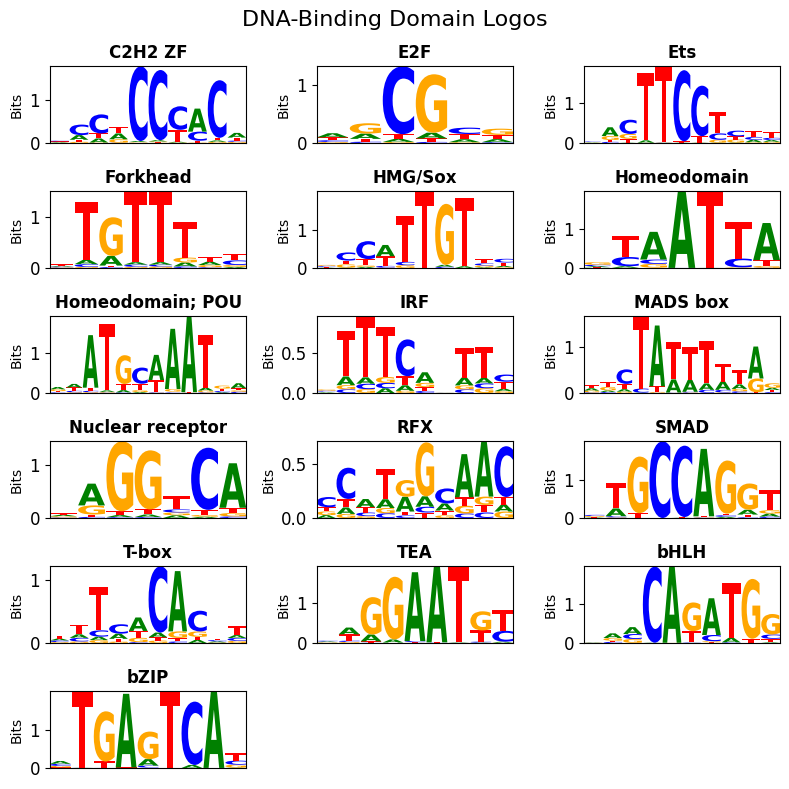

In [6]:
tm.pl.dbd_logos(
    patterns,
    ncols=3,
    ic_threshold=0.2,  # nucleotides in pattern below this will be trimmed
    min_nucleotides=4,  # ignore trimmed patterns less than 4 nucleotides (heterogeneous clusters)
)

Alternatively, we can also inspect the heterogeneity of the patterns by plotting the patterns for all clusters of a specific DBD using {func}`~tfmindi.pl.dbd_cluster_logos`.

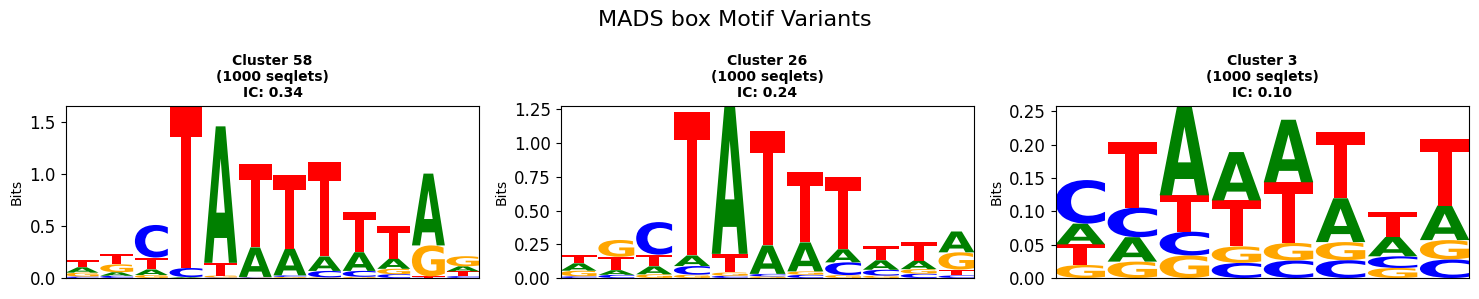

In [9]:
# Let's inspect all assigned MADS box variants
tm.pl.dbd_cluster_logos(
    patterns,
    dbd_name="MADS box",
    ic_threshold=0.2,  # nucleotides in pattern below this will be trimmed
    min_nucleotides=4,  # ignore trimmed patterns less than 4 nucleotides (heterogeneous clusters)
    ncols=3,
    width=15,
    height=3,
)

Instead of looking at the DBD motifs per cluster, we can also look the DBD motifs per **cell type**.  
Since each of our regions came from a cell type-specific enhancer and we know which seqlets came from which region, we can count the number of seqlets per DBD assignments and cell type.  
This will show us the DBD-cell type relationship.  
These are best visualized in a heatmap using {func}`~tfmindi.pl.dbd_heatmap`.

/data/groups/vib.ai/stein.aerts/lmahieu/projects/TF-MInDi/src/tfmindi/pl/_utils.py:137: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  fig.tight_layout()


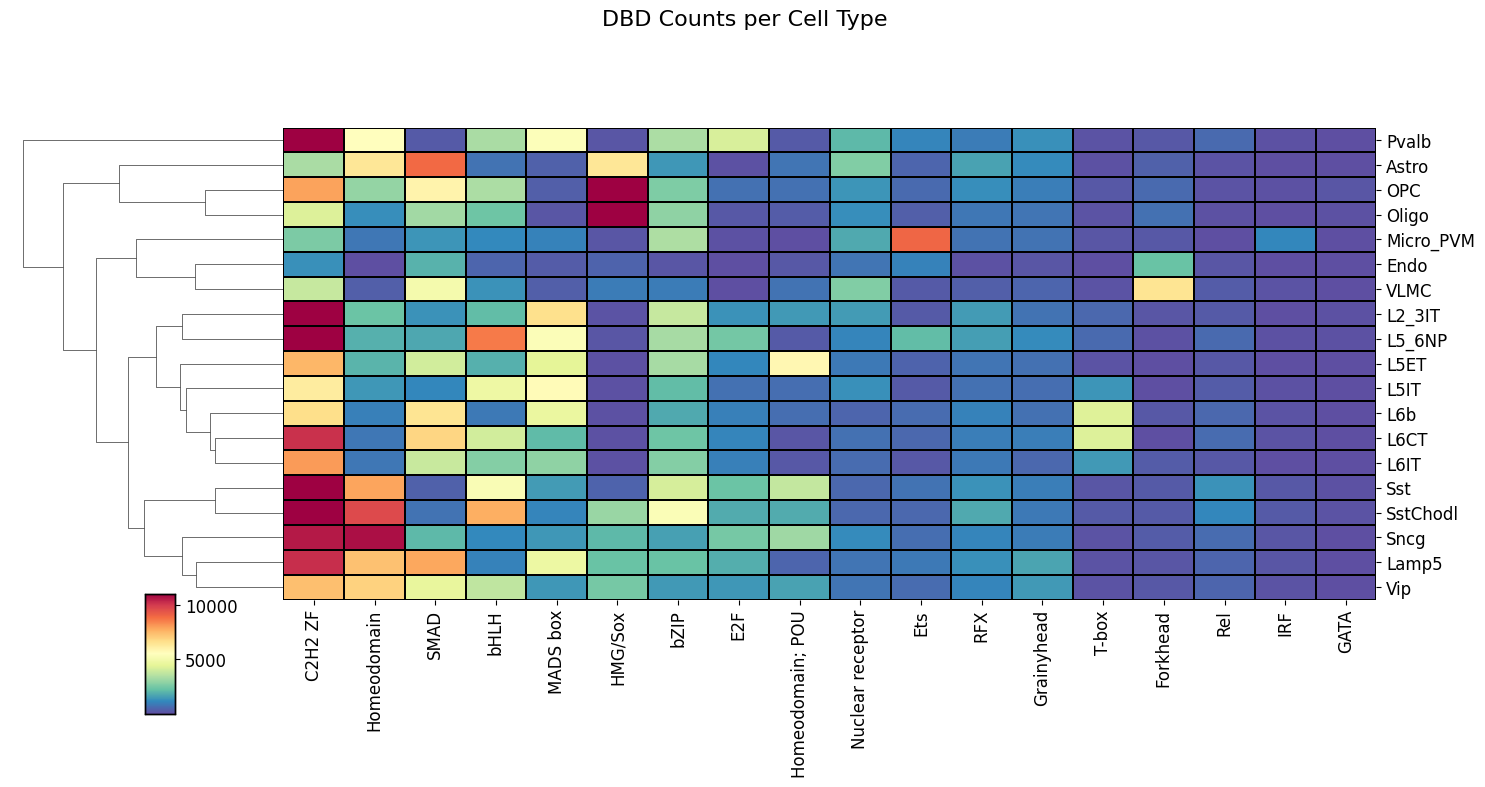

In [15]:
tm.pl.dbd_heatmap(
    adata,
    width=15,
    x_label_rotation=90,
    standard_scale=False,  # set to True to normalize rows accross cell types
    col_cluster=False,  # turn of the DBD clustering
)

## Annotating regions with DBDs

Since we have DBD annotations on a seqlet level after clustering, we can annotate our full regions that we used to extract the seqlets.  
This can be done using {func}`~tfmindi.pl.region_contributions`.

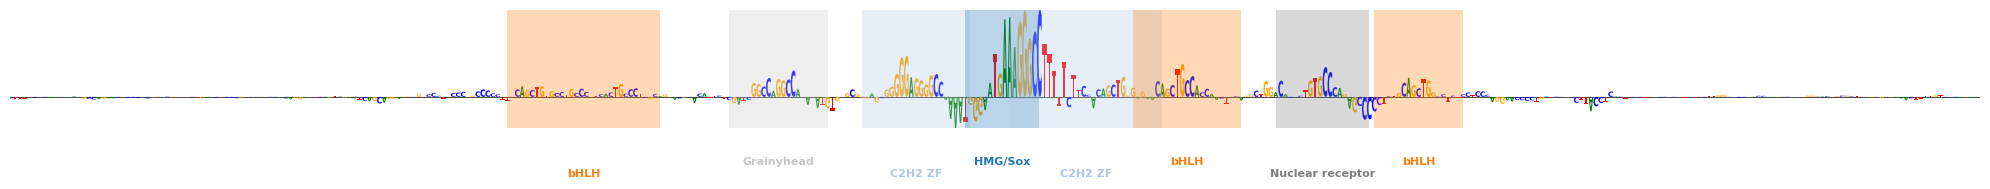

In [16]:
example_idx = 19895  # random region idx
tm.pl.region_contributions(
    adata,
    example_idx=example_idx,
    zoom_start=900,
    zoom_end=1300,  # focus on center 400bp
    min_attribution=3,  # ignore seqlets below this (absolute) threshold
    height=2,
    width=20,
)

Optionally, we can choose to only label certain DBDs.  

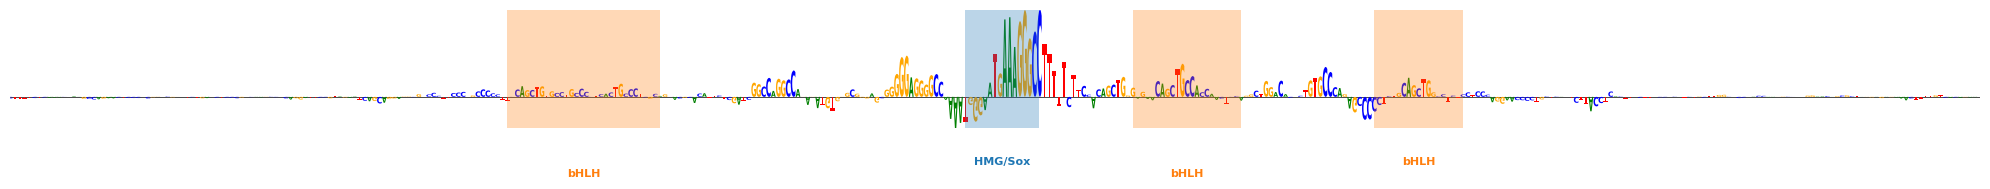

In [17]:
example_idx = 19895  # random region idx
tm.pl.region_contributions(
    adata,
    dbd_names=["HMG/Sox", "bHLH"],  # only show seqlets with these DBDs
    example_idx=example_idx,
    zoom_start=900,
    zoom_end=1300,  # focus on center 400bp
    min_attribution=3,  # ignore seqlets below this (absolute) threshold
    height=2,
    width=20,
)